# test mugem RVs


In [1]:
import numpy as np
import matplotlib.pylab as plt
from astropy.io import fits
import glob, sys, argparse, os, warnings
from datetime import datetime,timezone
%matplotlib widget

plt.ion()

from parvi_ccf_tools import *

warnings.filterwarnings('ignore', message='All-NaN slice encountered', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='Mean of empty slice', category=RuntimeWarning)

##############
# note copied data from /scr3/asjlin/parvi_data/spec_master2025_hybridwavesol_pad45/MuGem/
mode = 'mugem'

CONFIGS = {
    'mugem': {
        'datapath':   './data/MuGem/',
        'mask_sci':   './masks/ccf_mask_MuGem.csv',
        'mask_cal':   './masks/parvi_redetalon_ccf_mask_cal.csv',
        'rv_csv':     'mugem_rvs.csv',
        'orders_csv': 'mugem_rvs_byorder.csv',
        'label':      'Mu Gem',
        'wavelength_file': './parvi_wavesol_UNe+LFC_20251028_45orders_switchech107.fits',
        'output': 'outputs/mugem/',
        'orders_to_run': np.array([9,10, 33,35])
    }
}
cfg = CONFIGS[mode]
os.makedirs(cfg['output'], exist_ok=True)
DATETAG = '20251017'

In [2]:
def run_ccf_order(wave, flux, mask, iorder, R=70000, nsamp=3, starting_rv_guess=-20):
    """Run CCF for a single order of a general spectrum.

    wave, flux: 2D arrays (norders x npix)
    mask:       pandas df with order, cen, weight columns
    Returns rv_fit (float, km/s)
    """
    SPEEDOFLIGHT = 299792.458  # km/s
    mask_wid = (SPEEDOFLIGHT / R) / nsamp
    velocity_loop = np.arange(-50, 50, mask_wid / 4)

    mask_order = mask[mask['order'] == iorder]
    if len(mask_order['cen'].values) <= 2:
        return np.nan

    try:
        ccf_out, _ = ccf.ccf_make(
            wave[iorder], flux[iorder],
            mask_order['cen'].values, mask_wid * 10,
            mask_order['weight'].values, velocity_loop,
            R=R, nsamp=nsamp
        )
        rv_fit, _, _, _ = ccf.fit_gaussian_to_ccf_2(
            velocity_loop, ccf_out / np.max(ccf_out),
            starting_rv_guess, velocity_halfrange_to_fit=20.0, stddev_guess=1
        )
    except:
        rv_fit = np.nan
        print(f'error in CCF for order {iorder}')

    return rv_fit

In [3]:
files = np.sort(glob.glob(cfg['datapath'] + f'*{DATETAG}*fits'))
nfiles = len(files)
print(f'Loaded {nfiles} files for date {DATETAG} for the {mode} etalon')


Loaded 78 files for date 20251017 for the mugem etalon


In [4]:
mask_sci = load_mask(cfg['mask_sci'])
mask_cal = load_mask(cfg['mask_cal'])

mask_sci['cen']/=10
print(mask_sci['cen'].values)

[1217.48352279 1230.73276696 1232.0238155  1232.13331938 1232.24243698
 1235.98277877 1236.34833724 1238.95222243 1239.40441368 1239.57906852
 1239.83961114 1240.15767349 1241.27024801 1241.41213624 1242.15502644
 1242.35875437 1242.77755938 1242.86669689 1243.17874444 1246.26601482
 1246.47749763 1247.88148971 1248.8759873  1249.03074456 1249.11803929
 1249.37576451 1250.8787085  1251.37356284 1251.48819459 1251.62294568
 1252.22895074 1253.34334929 1275.56731117 1281.7336103  1282.75106418
 1285.28941646 1544.86755749 1555.74914839 1557.89931096 1558.32309641
 1559.13020896 1561.62109663 1561.80188271 1561.94635319 1563.4398931
 1588.85884626 1589.82826053 1589.93317151 1590.63994796 1591.15126809
 1591.30596796 1593.18708925 1593.66150204 1593.8416298  1595.24488655
 1595.53592217 1595.70196075 1652.77172191 1671.98747363 1682.80126474]


(3, 45, 2048)


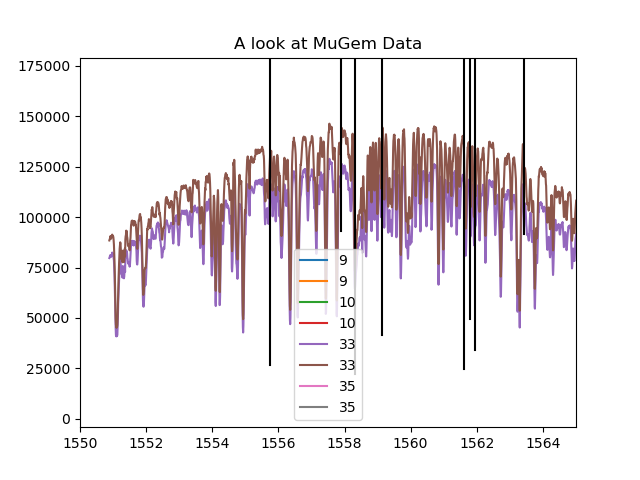

In [5]:
# plot some data
sci, cal = load_parvi_data(files[0])
sci2, cal2 = load_parvi_data(files[2])
w_sci, w_cal = load_wavelength_array(cfg['wavelength_file'])

print(np.shape(sci))
iorders = cfg['orders_to_run']
plt.figure()
for iorder in iorders:
    plt.plot(w_sci[iorder],sci[1][iorder],label=iorder)
    plt.plot(w_sci[iorder],sci2[1][iorder],label=iorder)

plt.xlim(1550, 1565)
for line in np.arange(len(mask_sci['cen'])):
    plt.axvline(mask_sci['cen'].values[line], mask_sci['weight'].values[line],c='k')

plt.legend()
plt.title('A look at MuGem Data')
plt.savefig(os.path.join(cfg['output'], 'mugem_spectrum_overview.png'), dpi=150, bbox_inches='tight')

# note one of th liens looks like a bad pixel


## Check the CCF

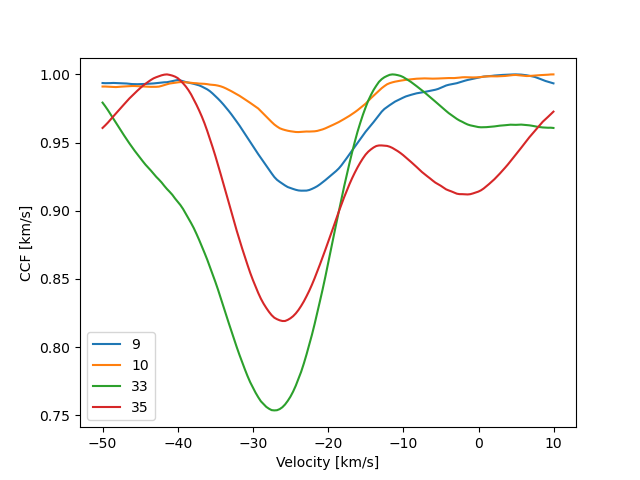

In [6]:
# CHECK CCF
iorder = 9
R = 70000
nsamp = 3

# Run one CCF for one order to check what the CCF looks like
SPEEDOFLIGHT = 299792.458  # km/s
mask_wid = (SPEEDOFLIGHT / R) / nsamp
velocity_loop = np.arange(-50, 10, mask_wid / 4)

#print(mask_order)

plt.figure()
ccfs = {}
for iorder in iorders:
    mask_order = mask_sci[mask_sci['order'] == iorder]
    ccf_out, _ = ccf.ccf_make(
        w_sci[iorder], sci[1][iorder],
        mask_order['cen'].values, mask_wid * 10,
        mask_order['weight'].values, velocity_loop,
        R=R, nsamp=3
    )
    ccfs[iorder] = ccf_out

    plt.plot(velocity_loop, ccf_out/np.max(ccf_out),label=iorder)

plt.xlabel('Velocity [km/s]')
plt.ylabel('CCF [km/s]')
plt.legend()
plt.savefig(os.path.join(cfg['output'], 'mugem_ccf_check_all_orders.png'), dpi=150, bbox_inches='tight')

No significant peak found in CCF. mean,stddev,amplitude,offset=[-25.64482617  11.31755416   0.14120046   0.04681258]
-25.735030885787143


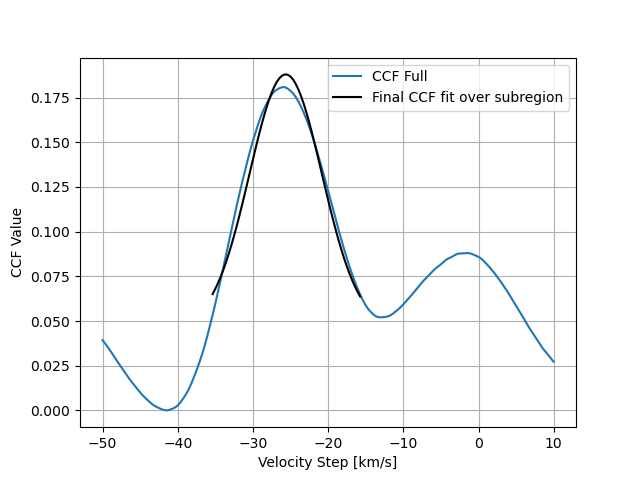

In [7]:
iorder = iorders[3]
mask_order = mask_sci[mask_sci['order'] == iorder]
ccf_out, _ = ccf.ccf_make(
    w_sci[iorder], sci[1][iorder],
    mask_order['cen'].values, mask_wid * 10,
    mask_order['weight'].values, velocity_loop,
    R=R, nsamp=3
)
ccfs[iorder] = ccf_out

# FIT CCF
rv_fit, fitx, fity, xi2 = ccf.fit_gaussian_to_ccf_2(
    velocity_loop, 1-ccf_out / np.max(ccf_out),
    -20, velocity_halfrange_to_fit=10.0, stddev_guess=1
)

print(rv_fit)
plt.figure()
plt.plot(velocity_loop, 1 - ccf_out / np.max(ccf_out),label='CCF Full')
plt.plot(fitx, fity,'k',label='Final CCF fit over subregion')
plt.legend()
plt.xlabel('Velocity Step [km/s]')
plt.ylabel('CCF Value')
plt.grid()
plt.savefig(os.path.join(cfg['output'], f'mugem_ccf_gaussian_fit_order{iorder}.png'), dpi=150, bbox_inches='tight')
plt.show()

## Run all orders

In [8]:
rvs = np.zeros((len(files), len(cfg['orders_to_run'])))
rvs_cal = np.zeros((len(files), len(cfg['orders_to_run'])))

w_sci, w_cal = load_wavelength_array(cfg['wavelength_file'])
for i, file in enumerate(files):
    sci, cal = load_parvi_data(file)
    for j, iorder in enumerate(cfg['orders_to_run']):
        rvs[i, j]     = run_ccf_order(w_sci, sci[1], mask_sci, iorder)
        rvs_cal[i, j] = run_ccf_order(w_cal, cal[1], mask_cal, iorder)


mjd_all = np.zeros((len(files)))
for i, file in enumerate(files):
    mjd_all[i] = load_parvi_metadata(file)


(78, 4)
78


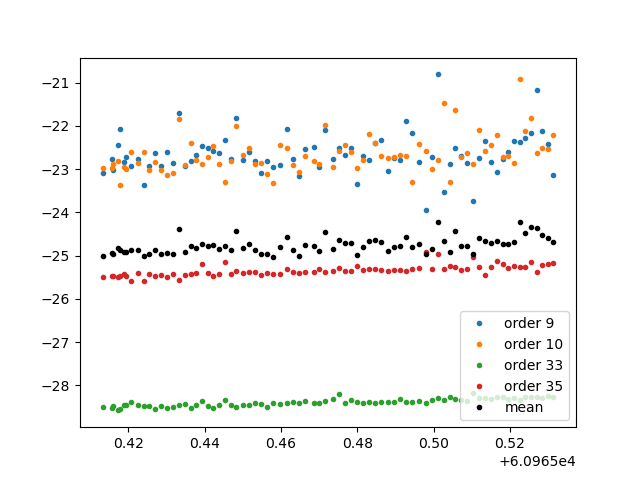

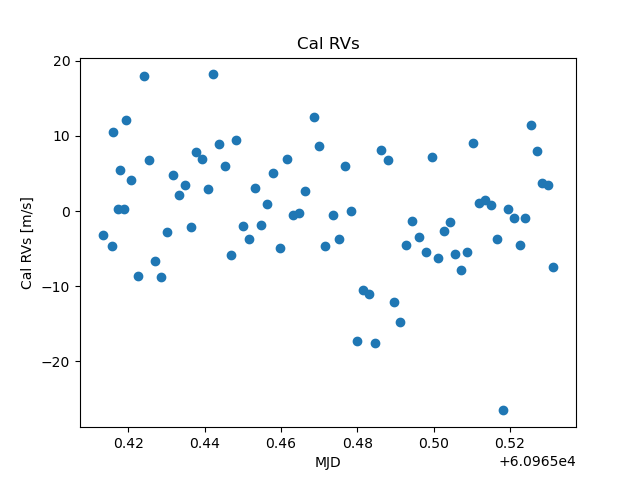

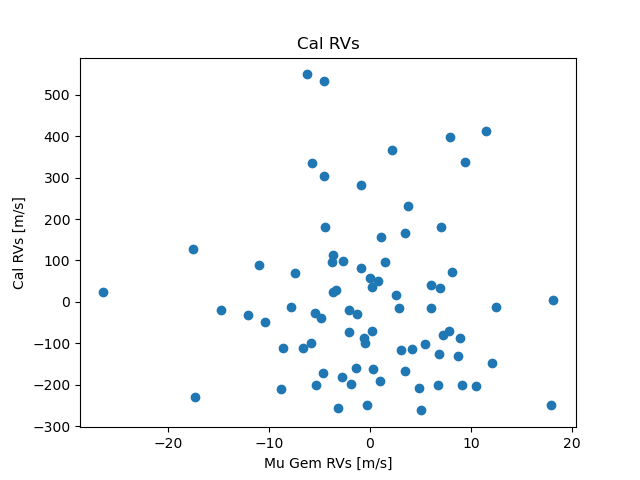

In [9]:
print(np.shape(rvs))
print(len(files))

fig1 = plt.figure()
mean_rvs_ms = np.mean(rvs,axis=1) * 1000
plt.plot(mjd_all, rvs[:,0],'.',label=f'order {iorders[0]}')
plt.plot(mjd_all, rvs[:,1],'.',label=f'order {iorders[1]}')
plt.plot(mjd_all, rvs[:,2],'.',label=f'order {iorders[2]}')
plt.plot(mjd_all, rvs[:,3],'.',label=f'order {iorders[3]}')
plt.plot(mjd_all, np.mean(rvs,axis=1),'k.',label='mean')
plt.legend()
fig1.savefig(os.path.join(cfg['output'], 'mugem_rv_by_order_vs_mjd.png'), dpi=150, bbox_inches='tight')


fig2 = plt.figure()
cal_rvs_ms = np.mean(rvs_cal,axis=1) * 1000
plt.plot(mjd_all, cal_rvs_ms - np.mean(cal_rvs_ms),'o')
plt.title('Cal RVs')
plt.xlabel('MJD')
plt.ylabel('Cal RVs [m/s]')
fig2.savefig(os.path.join(cfg['output'], 'mugem_cal_rvs_vs_mjd.png'), dpi=150, bbox_inches='tight')


fig3 = plt.figure()
plt.plot(cal_rvs_ms - np.mean(cal_rvs_ms), mean_rvs_ms - np.mean(mean_rvs_ms),'o')
plt.title('Cal RVs')
plt.xlabel('Mu Gem RVs [m/s]')
plt.ylabel('Cal RVs [m/s]')
fig3.savefig(os.path.join(cfg['output'], 'mugem_cal_vs_sci_rv_scatter.png'), dpi=150, bbox_inches='tight')


## Get BC vel and airmass

Mu Gem: 06h22m57.6268632s +22d30m48.8979s
airmass range: 1.018 - 1.223
barycentric correction range: 28.1229 to 28.3926 km/s


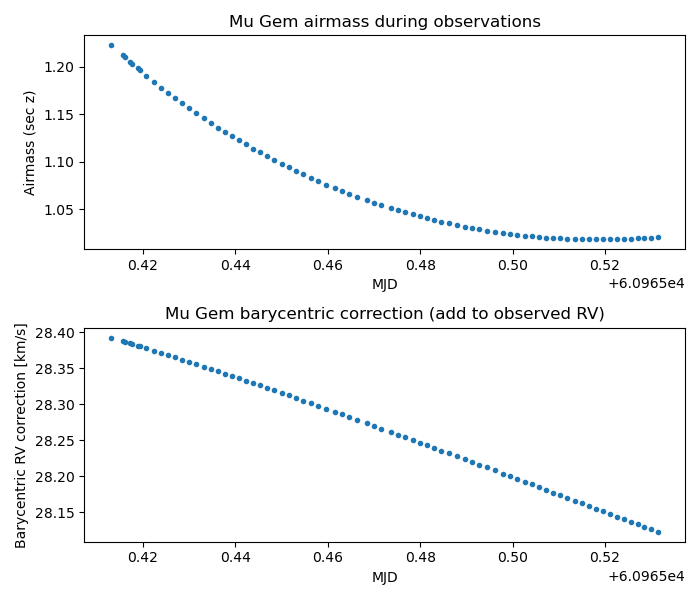

In [10]:
# --- Mu Gem (mu Gem / HD 44478 / HR 2286) J2000 coordinates ---
# Headers don't have RA/DEC/P200_AIR populated, so we supply the catalog
# position ourselves and derive airmass + barycentric correction from it.
# (NOTE: SkyCoord.from_name('mu Gem') resolves correctly; the capitalized
# 'Mu Gem' clashes with an unrelated GCVS variable-star designation.)
import astropy.units as u
from astropy.coordinates import SkyCoord
from parvi_ccf_tools import compute_airmass_barycorr

target_coord = SkyCoord(ra=95.74011193 * u.deg, dec=22.51358275 * u.deg, frame='icrs')
print('Mu Gem:', target_coord.to_string('hmsdms'))

airmass_all, barycorr_all = compute_airmass_barycorr(mjd_all, target_coord.ra.deg, target_coord.dec.deg)

print(f'airmass range: {np.nanmin(airmass_all):.3f} - {np.nanmax(airmass_all):.3f}')
print(f'barycentric correction range: {np.nanmin(barycorr_all):.4f} to {np.nanmax(barycorr_all):.4f} km/s')

fig, axes = plt.subplots(2, 1, figsize=(7, 6))
axes[0].plot(mjd_all, airmass_all, '.')
axes[0].set_xlabel('MJD')
axes[0].set_ylabel('Airmass (sec z)')
axes[0].set_title('Mu Gem airmass during observations')

axes[1].plot(mjd_all, barycorr_all, '.')
axes[1].set_xlabel('MJD')
axes[1].set_ylabel('Barycentric RV correction [km/s]')
axes[1].set_title('Mu Gem barycentric correction (add to observed RV)')
fig.tight_layout()
fig.savefig(os.path.join(cfg['output'], 'mugem_airmass_barycorr_vs_time.png'), dpi=150, bbox_inches='tight')

A=0.6480 km/s/airmass,  offset=-25.4613 km/s,  slope=3.896837 km/s/day


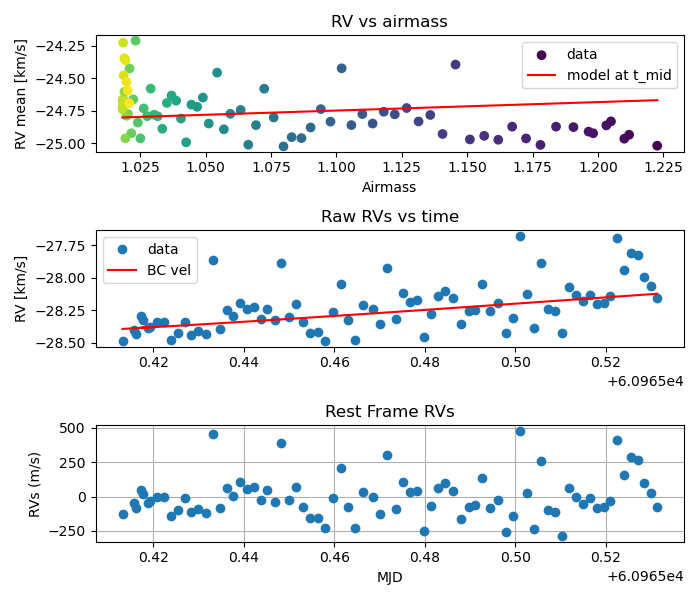

In [11]:
## Airmass + linear trend fit

# airmass_all, mjd_all computed above from SkyCoord + compute_airmass_barycorr
# (header P200_AIR / RA / DEC are not populated for these files)

# mean RV over orders (use only orders with valid fits)
rv_mean = np.nanmean(rvs, axis=1)
t_mid   = np.nanmean(mjd_all)

# model: A * airmass + offset + slope * (t - t_mid)
def airmass_model(X, A, offset, slope):
    airmass, t = X
    return A * airmass + offset + slope * (t - t_mid)

from scipy.optimize import curve_fit

ok = np.isfinite(rv_mean) & np.isfinite(airmass_all) & np.isfinite(mjd_all)
popt, pcov = curve_fit(airmass_model, (airmass_all[ok], mjd_all[ok]), rv_mean[ok], p0=[0, np.nanmean(rv_mean), 0])
A_fit, offset_fit, slope_fit = popt
print(f'A={A_fit:.4f} km/s/airmass,  offset={offset_fit:.4f} km/s,  slope={slope_fit:.6f} km/s/day')

rv_model = airmass_model((airmass_all, mjd_all), *popt)

fig, axes = plt.subplots(3,1, figsize=(7, 6))

axes[0].scatter(airmass_all, rv_mean, c=mjd_all, cmap='viridis', label='data')
axes[0].plot(np.sort(airmass_all), airmass_model((np.sort(airmass_all), t_mid), *popt), 'r-', label='model at t_mid')
axes[0].set_xlabel('Airmass')
axes[0].set_ylabel('RV mean [km/s]')
axes[0].set_title('RV vs airmass')
axes[0].legend()

bcvel_offset = -1*barycorr_all[0] - np.mean(rv_mean[0:3])
axes[1].plot(mjd_all, rv_mean + bcvel_offset, 'o', label='data')
#axes[1].plot(mjd_all, rv_model + bcvel_offset, 'r-', label='airmass + slope fit')
axes[1].plot(mjd_all, -1 * barycorr_all, 'r-', label='BC vel')

axes[1].set_ylabel('RV [km/s]')
axes[1].set_title('Raw RVs vs time')
axes[1].legend()

#axes[2].plot(mjd_all, rv_mean - rv_model, 'k--', alpha=0.5, label='residual')
bc_corrected_rvs_ms = (rv_mean + barycorr_all) * 1000
axes[2].plot(mjd_all, bc_corrected_rvs_ms - np.mean(bc_corrected_rvs_ms),'o')
axes[2].grid()
axes[2].set_ylabel('RVs (m/s)')
axes[2].set_xlabel('MJD')
axes[2].set_title('Rest Frame RVs')

fig.tight_layout()
fig.savefig(os.path.join(cfg['output'], 'mugem_airmass_trend_fit_summary.png'), dpi=150, bbox_inches='tight')